In [1]:
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# import plotly.express as px

In [2]:
load_dotenv()
database_url = os.getenv('DATABASE_URL')

engine = create_engine(database_url)

df = pd.read_sql('SELECT * FROM storm_events_details_cleaned', engine)

Creating a function where it changes the K's, M's and B's in damages to being actually float values

In [3]:
def written_to_full_amount(row):
    if row[-1:] == 'K':
        return float(row[:-1]) * 1000
    elif row[-1:] == 'M':
        return float(row[:-1]) * 1000000
    elif row[-1:] == 'B':
        return float(row[:-1]) * 1000000000
    else:
        return float(row)

In [4]:
df['DAMAGE_CROPS'].iloc[1][-1:]

'K'

In [5]:
df['DAMAGE_PROPERTY_FLOAT'] = df['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df['DAMAGE_CROPS_FLOAT'] = df['DAMAGE_CROPS'].apply(written_to_full_amount)
df['Total_Damage_Cost'] = df['DAMAGE_CROPS_FLOAT'] + df['DAMAGE_PROPERTY_FLOAT']
df['END_DATE_TIME_DT'] = df['END_DATE_TIME'].apply(pd.to_datetime)

In [6]:
df['END_DATE_TIME_DT']

0       2025-03-31 11:06:00
1       2025-03-30 15:55:00
2       2025-06-19 15:29:00
3       2025-04-05 17:35:00
4       2025-04-05 04:25:00
                ...        
28462   2025-06-11 14:51:00
28463   2025-06-03 18:05:00
28464   2025-06-03 18:10:00
28465   2025-06-03 18:22:00
28466   2025-06-03 19:15:00
Name: END_DATE_TIME_DT, Length: 28467, dtype: datetime64[ns]

In [7]:
df.sort_values(by='Total_Damage_Cost',ascending=False)
df_outlier = df[df['Total_Damage_Cost'] <= 1000000000]

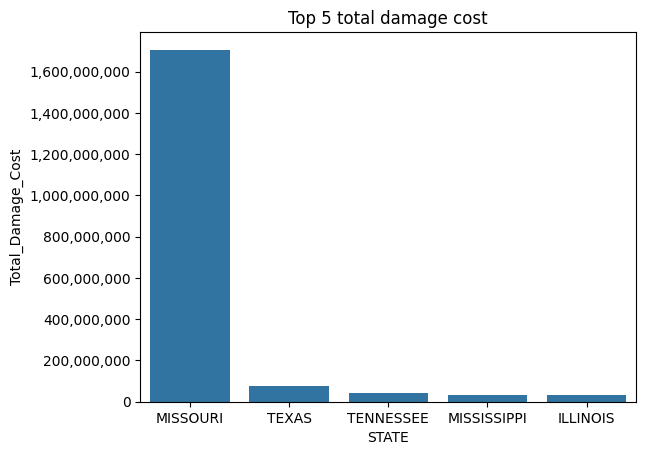

In [8]:
Grouped_State_df = df.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df

ax = sns.barplot(Grouped_State_df.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

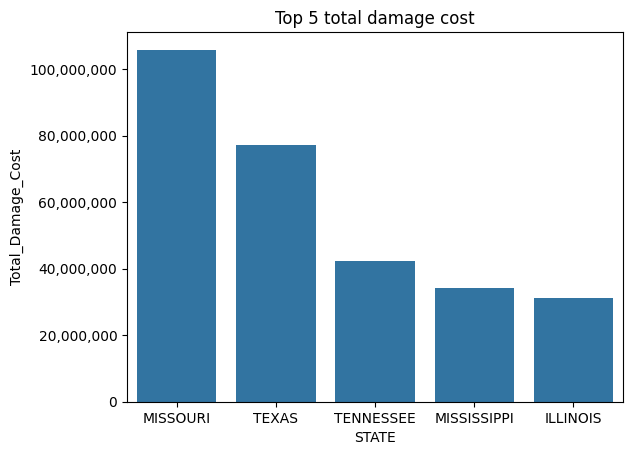

In [9]:
Grouped_State_df_out = df_outlier.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df_out

ax = sns.barplot(Grouped_State_df_out.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

In [10]:
US_STATE_ABBREV = {
    'ALABAMA': 'AL',
    'ALASKA': 'AK',
    'ARIZONA': 'AZ',
    'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA',
    'COLORADO': 'CO',
    'CONNECTICUT': 'CT',
    'DELAWARE': 'DE',
    'FLORIDA': 'FL',
    'GEORGIA': 'GA',
    'HAWAII': 'HI',
    'IDAHO': 'ID',
    'ILLINOIS': 'IL',
    'INDIANA': 'IN',
    'IOWA': 'IA',
    'KANSAS': 'KS',
    'KENTUCKY': 'KY',
    'LOUISIANA': 'LA',
    'MAINE': 'ME',
    'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA',
    'MICHIGAN': 'MI',
    'MINNESOTA': 'MN',
    'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO',
    'MONTANA': 'MT',
    'NEBRASKA': 'NE',
    'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH',
    'NEW JERSEY': 'NJ',
    'NEW MEXICO': 'NM',
    'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC',
    'NORTH DAKOTA': 'ND',
    'OHIO': 'OH',
    'OKLAHOMA': 'OK',
    'OREGON': 'OR',
    'PENNSYLVANIA': 'PA',
    'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD',
    'TENNESSEE': 'TN',
    'TEXAS': 'TX',
    'UTAH': 'UT',
    'VERMONT': 'VT',
    'VIRGINIA': 'VA',
    'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI',
    'WYOMING': 'WY'
}

In [11]:
Grouped_State_df['STATE']

0            ALABAMA
1             ALASKA
2     AMERICAN SAMOA
3            ARIZONA
4           ARKANSAS
           ...      
61          VIRGINIA
62        WASHINGTON
63     WEST VIRGINIA
64         WISCONSIN
65           WYOMING
Name: STATE, Length: 66, dtype: object

In [12]:
Grouped_State_df['Total_Damage_Cost'].dtype
Grouped_State_df['STATE'] = Grouped_State_df['STATE'].map(US_STATE_ABBREV)
Grouped_State_df['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [13]:
Grouped_State_df_out['Total_Damage_Cost'].dtype
Grouped_State_df_out['STATE'] = Grouped_State_df_out['STATE'].map(US_STATE_ABBREV)
Grouped_State_df_out['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [14]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [15]:
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df_out,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)

fig.show()

In [16]:
# begin_yearmonth = 202501
# for x in range(begin_yearmonth, begin_yearmonth+7):


In [17]:
# df['END_DATE_TIME_DT'] = df['END_DATE_TIME_DT'].dt.to_period("M").dt.to_timestamp()
# df['END_DATE_TIME_DT'].nunique()

In [18]:
# nbformat
# plotly
# kaleido
# import plotly.io as pio

# fig = px.choropleth(
#     data_frame= df,
#     locations = 'STATE',
#     locationmode= 'USA-states',
#     color = 'Total_Damage_Cost',
#     scope = 'usa',
#     animation_frame= 'END_DATE_TIME_DT',
#     color_continuous_scale= 'Viridis'
# )


# fig.show()